<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/Daily_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 05 - Deep Learning & Vision : encadrer et nommer les poissons de l'aquarium

*Temps estimé : 60 minutes*

*Difficulté : 7/10* -> Si tu rencontres des difficultés, c'est donc NORMAL ! -> Je te montrerai tout dans la correction :)

**IMPORTANT** Si ta machine peine (moins de 16 GB de RAM, CPU un peu ancien), importe ce code sur Google Colab comme nous l'avons vu pour le précédent projet. L'entraînement dure environ 5 minutes sur un CPU de portable récent.

Let's Go :)
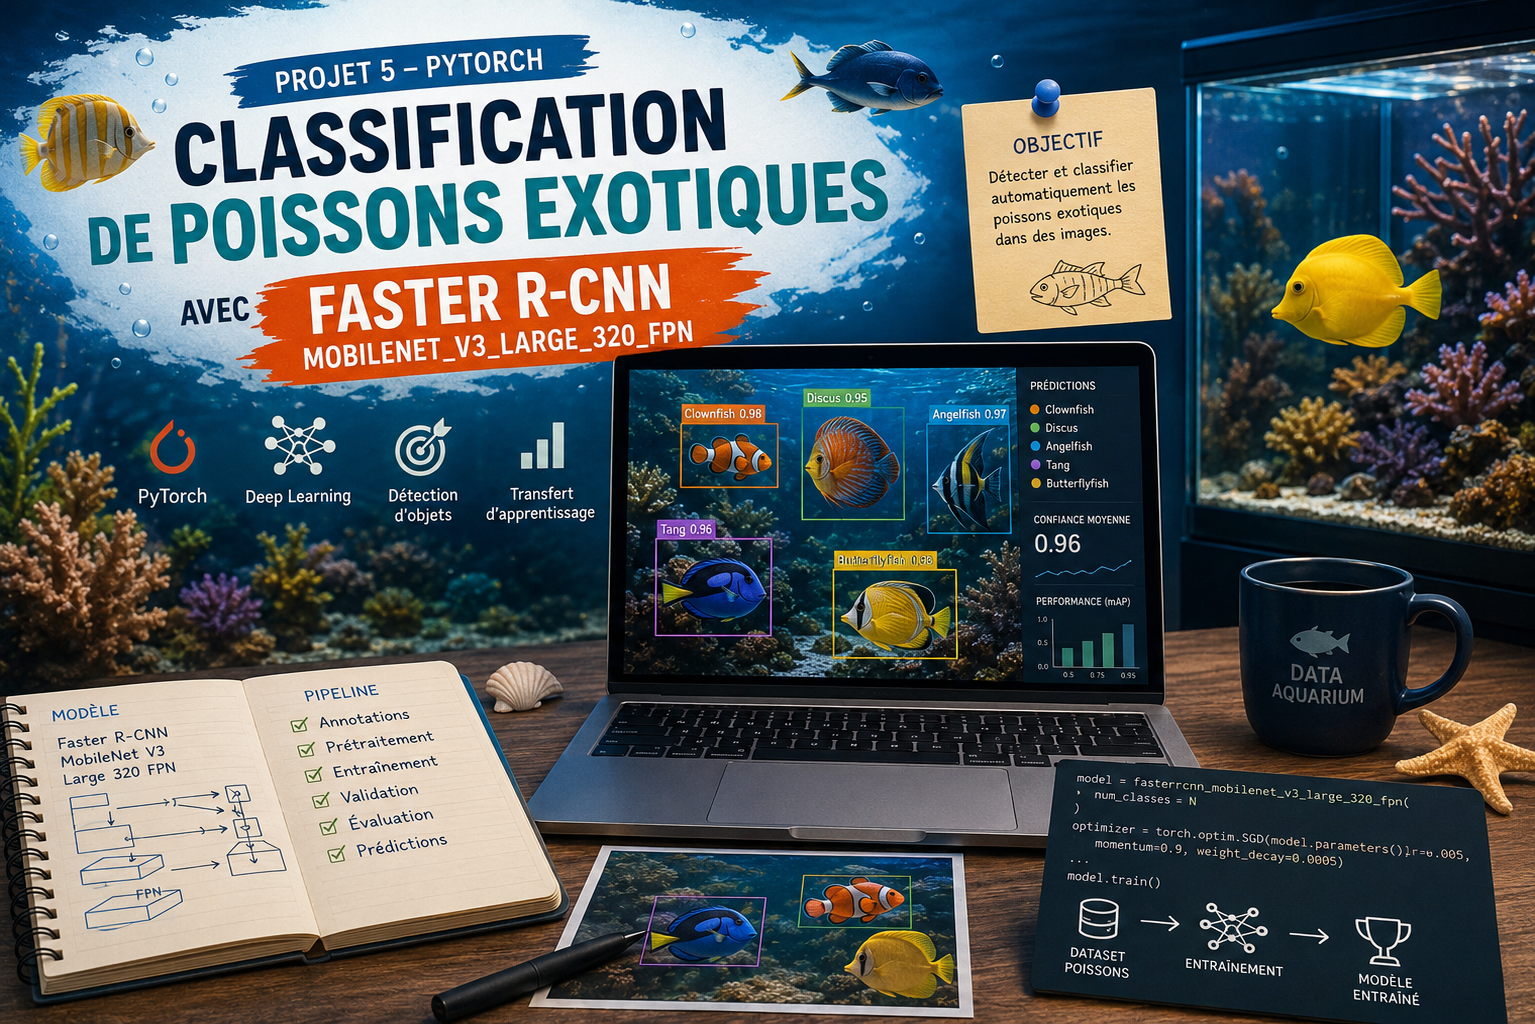

Ta nièce ne pointe plus un seul poisson isolé derrière une vitre : cette fois, c'est tout un bac récifal, une dizaine de poissons de plusieurs espèces qui nagent ensemble. « Et lui, c'est quoi ? Et celui-là, à côté ? » Ton prototype de la semaine dernière répondait bien à « quelle est l'espèce sur cette photo ? », à condition qu'il n'y ait qu'un seul poisson bien cadré. Face à une photo d'aquarium entier, il devrait choisir UNE réponse pour toute la scène : inutilisable ici.

Ce qu'il te faut cette fois, c'est une application qui entoure CHAQUE poisson d'un cadre et lui colle son étiquette d'espèce. Ça s'appelle la **détection d'objets** : deux questions à la fois, pour chaque objet présent, où est-il (sa boîte englobante) et qu'est-ce que c'est (son espèce).

Bonne nouvelle : le dataset Kaggle de la semaine dernière contenait déjà de vraies boîtes annotées à la main, une par poisson. Tu les avais ignorées pour garder les choses simples. Cette fois, on les utilise.

### Les outils du jour : Faster R-CNN

Le programme reste le même dans l'esprit qu'il y a une semaine : prendre un modèle pré-entraîné, observer ce qu'il sait déjà faire, puis le fine-tuner sur nos 13 espèces. Ce qui change, c'est l'architecture. Une simple classification (un vecteur de probabilités par image) ne suffit plus : il faut un réseau capable de proposer un nombre variable de boîtes, à des endroits variables, avec une espèce par boîte. Le modèle qu'on utilise s'appelle **Faster R-CNN** : il repère d'abord des centaines de régions "qui ressemblent à un objet" (le *Region Proposal Network*), puis classifie et affine chacune de ces régions.

Faster R-CNN a la réputation d'être lourd. torchvision propose heureusement une version bien plus légère, `fasterrcnn_mobilenet_v3_large_320_fpn` : le même principe, mais avec le MobileNetV3 comme squelette et une résolution interne réduite (320 pixels), pensée pour la vitesse. De quoi fine-tuner sur un simple CPU de portable, sans carte graphique.

### uv add : des librairies de plus

```bash
uv add torchvision kagglehub torchmetrics
```

`torchmetrics` fournit une implémentation prête à l'emploi du **mAP** (*mean Average Precision*), la métrique standard pour évaluer un détecteur d'objets : sa formule exacte est notoirement subtile, et la dériver à la main dépasserait largement le cadre de ce projet.

Le fichier `utils.py` s'occupe cette semaine de toute la plomberie autour des données (lire les fichiers d'annotation, construire le tableau des photos) et de tous les affichages, pour qu'on puisse se concentrer sur le Deep Learning. Jette-lui un oeil si tu es curieux, mais rien de ce qu'il contient n'est nouveau pour toi.

In [3]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.7 MB/s eta 0:00:00


In [4]:
import os
import random

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.transforms import v2 as T
import torchvision.transforms.v2.functional as F
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import kagglehub

from utils import (SPECIES, build_fish_dataframe, collate_fn, compute_map, label_path_for,
                   list_images, plot_boxes, plot_ground_truth_grid, plot_loss_curves,
                   plot_predictions_grid, plot_species_counts, read_yolo_boxes)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Partie 1 - Les poissons (et leurs boîtes) de Kaggle

Voici le dataset pour cette semaine : [`fish-dataset`](https://www.kaggle.com/datasets/mahmoodyousaf/fish-dataset) : plus de 8 200 photos de 13 espèces de poissons d'aquarium, réparties en trois lots (entraînement, validation, test), au format YOLO.

In [5]:
# Télécharge le dataset (environ 350 Mo, une seule fois : les exécutions suivantes réutilisent le cache local)
DATASET_DIR = kagglehub.dataset_download("mahmoodyousaf/fish-dataset", output_dir="data")

print("Dataset téléchargé dans :", DATASET_DIR)

100%|██████████| 342M/342M [00:22<00:00, 16.2MB/s]

Extracting files...


Dataset téléchargé dans : data


Pour rappel, chaque photo a un fichier de labels associé (un `.txt` dans `data/train/labels`), avec une ligne par poisson : `classe x_centre y_centre largeur hauteur`, ces quatre derniers nombres étant exprimés en fraction de la largeur/hauteur de l'image (entre 0 et 1). L'indice de classe pointe vers la liste `SPECIES`.

Décoder ce format n'a rien de bien passionnant : `utils.py` s'en charge avec `read_yolo_boxes` (qui convertit une ligne YOLO en rectangle `[x1, y1, x2, y2]` en pixels) et `build_fish_dataframe` (qui parcourt les trois lots et construit un tableau d'une ligne par photo, avec son espèce dominante).

13 espèces : AngelFish, BlueTang, ButterflyFish, ClownFish, GoldFish, Gourami, MorishIdol, PlatyFish, RibbonedSweetlips, ThreeStripedDamselfish, YellowCichlid, YellowTang, ZebraFish


,image_path,species,split
0,data/train/images/001_jpg.rf.d47e7ce0fd847e561...,ButterflyFish,train
1,data/train/images/001_jpg.rf.eaa7c989ec5ef785a...,ButterflyFish,train
2,data/train/images/002_jpg.rf.130be8cea6916f0b2...,ButterflyFish,train
3,data/train/images/002_jpg.rf.2f5deb4bb969ad624...,ButterflyFish,train
4,data/train/images/002_jpg.rf.3468dfbec49bbe101...,ButterflyFish,train


7750 photos étiquetées au total


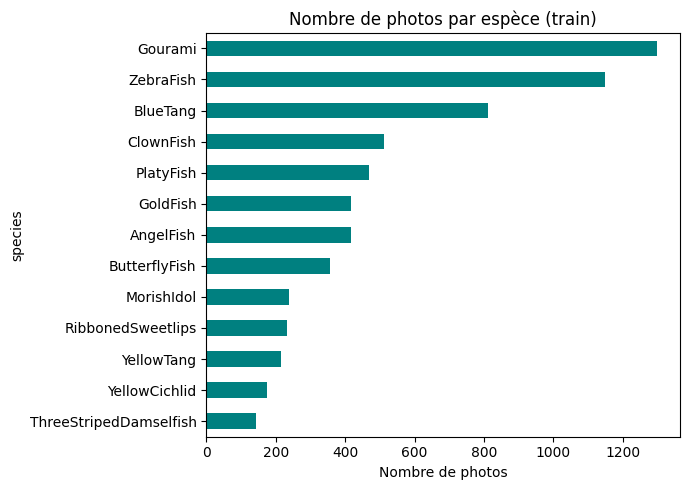

,count
species,
Gourami,1300
ZebraFish,1148
BlueTang,812
ClownFish,512
PlatyFish,468
GoldFish,418
AngelFish,416
ButterflyFish,356
MorishIdol,238


In [6]:
print(f"{len(SPECIES)} espèces : {', '.join(SPECIES)}")

fish_df = build_fish_dataframe(DATASET_DIR)
display(fish_df.head())
print(f"{len(fish_df)} photos étiquetées au total")

plot_species_counts(fish_df, split="train")

La répartition est loin d'être uniforme : un Gourami a presque 10 fois plus de photos qu'un YellowCichlid. On garde ça en tête, et on avance.

Un tableau de coordonnées, ça ne parle pas beaucoup : dessinons plutôt les vraies boîtes sur six photos d'entraînement tirées au hasard.

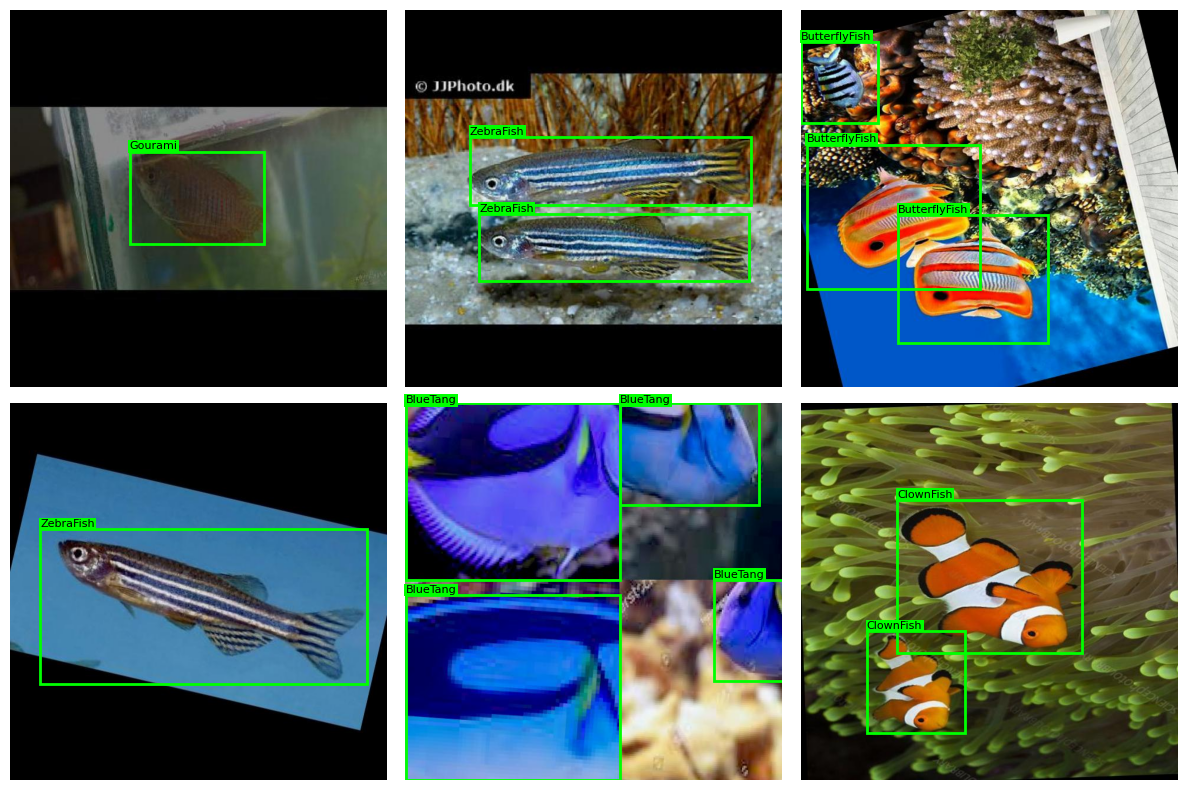

In [7]:
sample_paths = fish_df[fish_df["split"] == "train"]["image_path"].sample(n=6, random_state=SEED).tolist()
plot_ground_truth_grid(sample_paths)

# Partie 2 - Le détecteur pré-entraîné : un généraliste, mais pas de poissons

Le modèle `fasterrcnn_mobilenet_v3_large_320_fpn` est pré-entraîné sur **COCO**, un jeu de données de référence en détection d'objets (personnes, voitures, animaux domestiques, mobilier...), avec 91 catégories. Chargeons-le, et testons-le tel quel sur nos poissons.

In [8]:
weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT

coco_model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights).eval()  # le détecteur pré-entraîné, en évaluation
coco_categories = weights.meta["categories"]                               # les 91 catégories COCO

print(f"Faster R-CNN (MobileNetV3) chargé : {sum(p.numel() for p in coco_model.parameters()):,} paramètres")
print("Catégories COCO contenant 'fish' :", [c for c in coco_categories if "fish" in c.lower()] or "AUCUNE")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 159MB/s]


Faster R-CNN (MobileNetV3) chargé : 19,386,354 paramètres
Catégories COCO contenant 'fish' : AUCUNE


Sans surprise : COCO ne contient tout simplement aucune catégorie poisson. Voyons ce que le modèle propose quand même.

### Étape 1 : faire prédire un détecteur

Écris `predict` : elle prend un modèle et le chemin d'une image, fait tourner le détecteur, et ne garde que les boîtes dont le score de confiance dépasse `score_thresh`. C'est LA mécanique d'inférence en détection : tu la réutiliseras telle quelle à la fin du projet, avec ton modèle fine-tuné.

Quatre étapes :
1. charge l'image avec `read_image(image_path)[:3]` (le `[:3]` élimine un éventuel canal alpha), convertis-la en float normalisé avec `F.to_dtype(image, torch.float32, scale=True)`, puis ajoute une dimension de batch avec `.unsqueeze(0)`
2. passe ce batch dans le modèle (`with torch.no_grad():`) : il retourne une **liste** d'un seul dictionnaire (`"boxes"`, `"labels"`, `"scores"`), garde l'élément `[0]`
3. construis un masque booléen `keep` : les scores strictement supérieurs à `score_thresh`
4. filtre `"boxes"`, `"labels"` et `"scores"` avec ce masque, et traduis les indices de labels en noms avec `names`

> Indice : un tensor PyTorch se filtre directement avec un masque booléen, comme un tableau numpy (`tensor[mask]`). `.tolist()` convertit un tensor en liste Python.

In [9]:
def predict(model, image_path, names, score_thresh=0.5):
    """
    Run a detection model on an image and keep the detections above score_thresh.

    Arguments:
    model -- a torchvision detection model, in eval mode
    image_path -- path to an image file, of any resolution
    names -- list of category names, indexed by the label indices the model outputs
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of category names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    ### START CODE HERE ###

    # (1) Charge l'image, la normalise entre [0, 1] et crée un batch de 1 image
    image = read_image(image_path)[:3]
    batch = F.to_dtype(image, torch.float32, scale=True).unsqueeze(0)

    # (2) Passe le batch dans le modèle et récupère le dictionnaire de résultats
    with torch.no_grad():
        output = model(batch)[0]

    # (3) Masque booléen des détections ayant un score supérieur au seuil
    keep = output["scores"] > score_thresh

    # (4) Filtrage des 3 tensors et conversion en listes Python
    boxes = output["boxes"][keep].tolist()
    labels = [names[i] for i in output["labels"][keep].tolist()]
    scores = output["scores"][keep].tolist()

    ### END CODE HERE ###

    return boxes, labels, scores

Édifiant : sur un poisson rouge photographié de très près, le modèle voit... un "bird" (oiseau) ! Une deuxième photo pour confirmer :

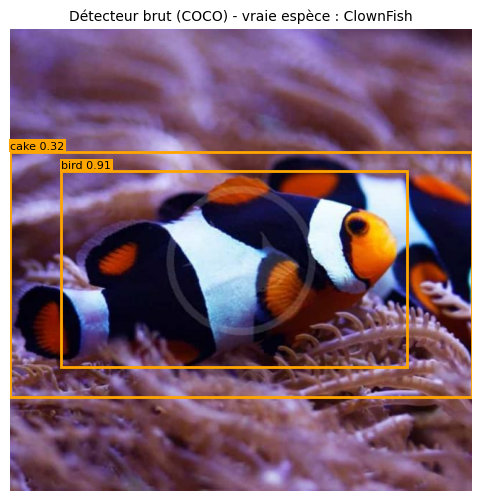

In [10]:
clownfish_path = os.path.join(DATASET_DIR, "train", "images",
                              "CLOWN-PERCULA-CLASSIC-AQUACULTURED-PAIR-Amphiprion-percula_jpg.rf.2d0bece80bf5100491a22972fee01a23.jpg")

boxes, labels, scores = predict(coco_model, clownfish_path, coco_categories, score_thresh=0.3)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, box_color="orange",
           title="Détecteur brut (COCO) - vraie espèce : ClownFish")

Même verdict pour le poisson-clown. COCO n'a purement et simplement jamais entendu parler de poissons, ni en tant que concept général, ni a fortiori en espèces. Le modèle localise pourtant plutôt bien la zone intéressante de l'image (le Region Proposal Network sait repérer "un objet"), il se trompe seulement sur ce que c'est. C'est encourageant : la moitié du travail (localiser) est déjà là, il reste à lui apprendre le reste (classifier correctement).

Petit bonus au passage : ce détecteur accepte des images de **taille variable**, il les redimensionne lui-même en interne et rescale les boîtes de sortie dans le repère de l'image d'origine. Une photo de téléphone en 4032 x 3024 peut lui être donnée telle quelle, sans aucun préprocessing manuel de notre part.

# Partie 3 - Le Dataset et les DataLoaders

On fine-tune **sans data augmentation** : impossible de savoir à l'avance si elle est vraiment utile sur ce dataset, donc on commence tel quel et on jugera après coup sur le mAP (voir *Pour aller plus loin* en fin de notebook). Seule transformation appliquée aux images : la conversion en float, valeurs entre 0 et 1. Pas de `Normalize` à ajouter, contrairement au projet précédent : ce détecteur normalise déjà les couleurs en interne.

### Étape 2 : le Dataset de détection

En détection, un échantillon n'est plus `(image, étiquette)` mais `(image, target)`, où `target` est un dictionnaire contenant **toutes** les boîtes de la photo et **toutes** leurs espèces. Complète `__getitem__` :

1. convertis `boxes` en tensor float de forme `(n, 4)`, et enveloppe-le dans un `tv_tensors.BoundingBoxes` (format `"XYXY"`, `canvas_size=(H, W)`) : c'est cet emballage qui permet aux transformations de bouger les boîtes en même temps que l'image
2. convertis les indices d'espèces en tensor d'entiers, **en ajoutant 1 à chacun** : la classe 0 est réservée au "fond" (l'absence d'objet) par convention dans torchvision, nos 13 espèces occupent donc les indices 1 à 13
3. applique `self.transforms` à l'image et à ce dictionnaire `target`

Un piège à connaître : certaines photos ne contiennent aucun poisson, et `class_indices` est alors une liste vide. Sans précaution, `torch.tensor([])` construit un tensor `float32`, alors que le modèle exige des labels en `int64` : précise toujours `dtype=torch.int64` explicitement.

> Indice :
> ```python
> boxes_t = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
> labels_t = torch.tensor([c + 1 for c in class_indices], dtype=torch.int64)
> target = {"boxes": tv_tensors.BoundingBoxes(boxes_t, format="XYXY", canvas_size=(H, W)), "labels": labels_t}
> image = tv_tensors.Image(image)
> if self.transforms:
>     image, target = self.transforms(image, target)
> ```

In [11]:
basic_transform = T.Compose([T.ToDtype(torch.float32, scale=True)])  # pas d'augmentation pour l'instant


class FishDetectionDataset(Dataset):
    def __init__(self, image_paths, transforms=None):
        self.image_paths = image_paths
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        """
        Return one (image, target) pair, ready for the detector.

        Returns:
        image -- image tensor, shape (3, H, W)
        target -- dict with keys "boxes" (tv_tensors.BoundingBoxes) and "labels" (tensor of ints, 1 to 13)
        """
        image_path = self.image_paths[i]
        image = read_image(image_path)[:3]
        H, W = image.shape[-2:]
        boxes, class_indices = read_yolo_boxes(label_path_for(image_path), W, H)

        ### START CODE HERE ###

        boxes_t =  torch.tensor(boxes,dtype=torch.float32).reshape(-1,4) # (1) les boîtes, en tensor (n, 4)
        labels_t = torch.tensor([c+1 for c in class_indices],dtype=torch.int64)  # (2) +1 : le fond est la classe 0
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes_t, format="XYXY", canvas_size=(H, W)),
            "labels": labels_t,
        }
        image = tv_tensors.Image(image)
        if self.transforms:
            # (3) même transformation appliquée à l'image et à ses boîtes
            image, target = self.transforms(image, target)

        ### END CODE HERE ###

        return image, target


demo_image, demo_target = FishDetectionDataset([clownfish_path], transforms=basic_transform)[0]
print(f"Image : {demo_image.shape}, {len(demo_target['labels'])} boîte(s), labels : {demo_target['labels'].tolist()}")

assert demo_target["boxes"].shape[1] == 4, "Chaque boîte doit avoir 4 coordonnées"
assert demo_target["labels"].dtype == torch.int64, "Les labels doivent être des entiers (int64)"
assert (demo_target["labels"] >= 1).all(), "Les labels doivent être décalés de +1 (0 est réservé au fond)"
print("Exercice validé !")

Image : torch.Size([3, 640, 640]), 1 boîte(s), labels : [4]
Exercice validé !


Il ne reste qu'à assembler nos lots. `MAX_TRAIN_IMAGES` limite le nombre de photos d'entraînement pour rester rapide sur un ordinateur portable : avec 1000 photos et 3 epochs, compte environ 5 minutes sur un CPU récent. Augmente ces valeurs si ta machine tient la charge, ou passe sur Google Colab.

`collate_fn` (fournie dans `utils.py`) sert à grouper les échantillons en batchs : en détection, les images et leur nombre de boîtes varient d'un échantillon à l'autre, on ne peut donc pas les empiler dans un seul tensor, on garde des listes.

In [12]:
MAX_TRAIN_IMAGES = 1000
MAX_VAL_IMAGES = 300  # sert à l'évaluation (Partie 5)
BATCH_SIZE = 4        # Réduire si manque de mémoire

all_train, all_val = list_images(DATASET_DIR, "train"), list_images(DATASET_DIR, "valid")
train_images = random.sample(all_train, min(MAX_TRAIN_IMAGES, len(all_train)))
val_images = random.sample(all_val, min(MAX_VAL_IMAGES, len(all_val)))

train_loader = DataLoader(FishDetectionDataset(train_images, transforms=basic_transform),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FishDetectionDataset(val_images, transforms=basic_transform),
                        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Entraînement : {len(train_images)} photos, {len(train_loader)} batchs de {BATCH_SIZE}")
print(f"Validation   : {len(val_images)} photos, {len(val_loader)} batchs de {BATCH_SIZE}")

Entraînement : 1000 photos, 250 batchs de 4
Validation   : 300 photos, 75 batchs de 4


# Partie 4 - Le fine-tuning

La logique : geler le corps du réseau (`model.backbone`), et n'entraîner vraiment que la tête de classification des boîtes (`model.roi_heads.box_predictor`).

### Étape 3 : adapter le modèle

Complète `build_model` :
1. gèle tous les paramètres de `model.backbone`
2. remplace `model.roi_heads.box_predictor` par un nouveau `FastRCNNPredictor(in_features, num_classes_with_background)`, où `in_features = model.roi_heads.box_predictor.cls_score.in_features` (le nombre d'entrées de la couche actuelle)

> Indice : `num_classes_with_background` vaut 14 dans notre cas (13 espèces + le fond).

In [13]:
def build_model(num_classes_with_background):
    """
    Load a pretrained Faster R-CNN (MobileNetV3 backbone) and adapt it to a new number of classes.

    Arguments:
    num_classes_with_background -- number of species to detect, PLUS the background class

    Returns:
    model -- the adapted model, with a frozen backbone and a new box-classification head
    """
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT)

    ### START CODE HERE ###

    # (1) On gèle le backbone : il sait déjà "voir"
    for p in model.backbone.parameters():
        p.requires_grad = False

    # (2) On récupère le nombre de caractéristiques en entrée
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # (3) On remplace la tête de prédiction par une nouvelle adaptée à nos classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_background)

    ### END CODE HERE ###

    return model


model = build_model(len(SPECIES) + 1)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{n_trainable:,} paramètres entraînables sur {sum(p.numel() for p in model.parameters()):,} au total")

assert model.roi_heads.box_predictor.cls_score.out_features == 14, "14 sorties attendues (13 espèces + fond)"
assert all(not p.requires_grad for p in model.backbone.parameters()), "model.backbone devrait être gelé"
print("Exercice validé !")

14,576,785 paramètres entraînables sur 18,991,729 au total
Exercice validé !


### Étape 4 : la boucle d'entraînement

Différence notable avec la classification : en mode entraînement (`model.train()`), appeler `model(images, targets)` **ne retourne pas des prédictions**, mais un dictionnaire de 4 losses (`loss_classifier`, `loss_box_reg`, `loss_objectness`, `loss_rpn_box_reg`), une par sous-partie du réseau. On les additionne pour obtenir la loss totale à rétropropager.

Complète la boucle :
1. calcule `loss_dict = model(images, targets)` (les deux sont déjà des listes, grâce à `collate_fn`)
2. calcule la loss totale : `loss = sum(loss_dict.values())`
3. rétropropage et mets à jour les poids : `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`

C'est parti pour environ 5 minutes de calcul : le bon moment pour aller te chercher un café.

In [15]:
NUM_EPOCHS = 3  # Réduire si trop lent
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)

loss_names = ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]
loss_history = {name: [] for name in loss_names}

for epoch in range(NUM_EPOCHS):
    model.train()
    running = {name: 0.0 for name in loss_names}
    n_batches = 0
    for images, targets in train_loader:
        images, targets = list(images), list(targets)

        ### START CODE HERE ###

        # (1) Passer le batch dans le modèle pour obtenir le dictionnaire de pertes
        loss_dict = model(images, targets)

        # (2) Sommer toutes les pertes pour obtenir la loss totale
        loss = sum(loss_dict.values())

        # (3) Gradients à zéro, rétropropagation et mise à jour des poids
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### END CODE HERE ###

        for name in loss_names:
            running[name] += loss_dict[name].item()
        n_batches += 1

    for name in loss_names:
        loss_history[name].append(running[name] / n_batches)
    print(f"epoch {epoch + 1}/{NUM_EPOCHS}  loss totale {sum(loss_history[name][-1] for name in loss_names):.3f}")

assert sum(loss_history[name][-1] for name in loss_names) < sum(loss_history[name][0] for name in loss_names), \
    "La loss totale devrait diminuer entre la première et la dernière epoch"
print("Exercice validé !")

epoch 1/3  loss totale 1.260
epoch 2/3  loss totale 0.923
epoch 3/3  loss totale 0.762
Exercice validé !


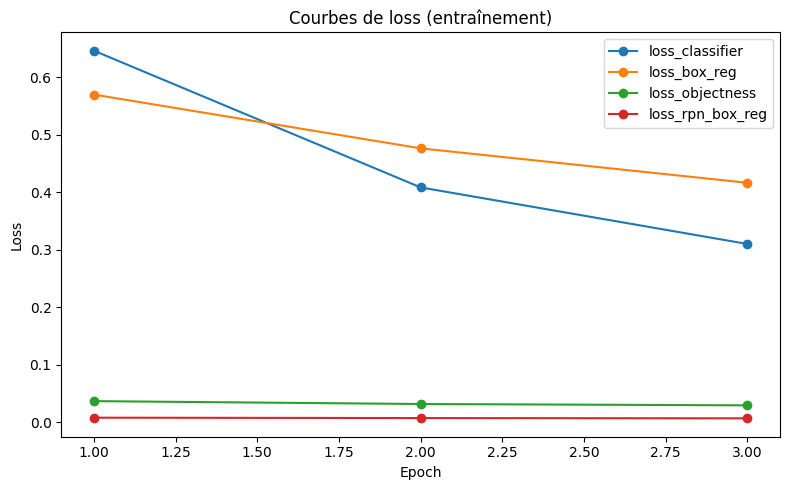

In [16]:
plot_loss_curves(loss_history, NUM_EPOCHS)

`loss_classifier` et `loss_box_reg` (est-ce le bon poisson, et la boîte est-elle bien placée) sont en général celles qui baissent le plus, car ce sont les seules parties du réseau vraiment concernées par NOS 13 espèces. `loss_objectness` et `loss_rpn_box_reg` viennent du Region Proposal Network, qui savait déjà repérer "un objet" grâce à son pré-entraînement COCO, et n'a donc pas grand-chose de nouveau à apprendre.

# Partie 5 - Le détecteur fine-tuné à l'oeuvre

### Étape 5 : encadrer et nommer chaque poisson

L'application que ta nièce attend. Tout le travail est déjà fait : il suffit d'appeler la fonction `predict` de l'Étape 1 avec le modèle fine-tuné, et avec la liste de noms qui correspond à SES sorties.

**Attention à l'indice** : à l'Étape 2, on a décalé nos espèces de +1 pour laisser la classe 0 au fond. La liste de noms à passer commence donc par le fond, puis les 13 espèces : un label de sortie `1` désignera bien `SPECIES[0]`.

> Indice : `names = ["fond"] + SPECIES`, puis `predict(model, image_path, names, score_thresh)`. N'oublie pas `model.eval()` avant de prédire : plus question de calculer des gradients, seulement de prédire.

1 détection(s) : [('ClownFish', 0.96)]
Exercice validé !


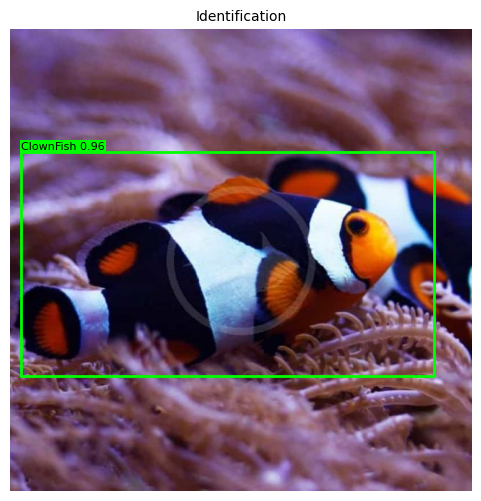

In [18]:
model.eval()


def identifier_et_encadrer_poissons(image_path, score_thresh=0.5):
    """
    Detect and identify every fish in a photo, using the fine-tuned model.

    Arguments:
    image_path -- path to an image file, of any resolution
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of species names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    ### START CODE HERE ###

    # (1) Décalage des classes : l'indice 0 est l'arrière-plan, 1+ sont nos espèces
    names = ["background"] + SPECIES

    # (2) Inférence avec le modèle fine-tuné via la fonction predict de l'Étape 1
    boxes, labels, scores = predict(model, image_path, names, score_thresh)

    ### END CODE HERE ###

    return boxes, labels, scores


boxes, labels, scores = identifier_et_encadrer_poissons(clownfish_path)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, title="Identification")

print(f"{len(boxes)} détection(s) : {list(zip(labels, [round(s, 2) for s in scores]))}")
assert all(label in SPECIES for label in labels), \
    f"Toutes les étiquettes doivent être des espèces (attention au décalage du fond), tu obtiens {labels}"
print("Exercice validé !")

Essaie maintenant avec tes propres photos : dépose une image dans le dossier du projet, et appelle `identifier_et_encadrer_poissons("mon_fichier.jpg")`. N'importe quelle résolution fait l'affaire, y compris une photo de téléphone brute : le modèle se charge du redimensionnement.

**Remarque** : le modèle ne connaît que les 13 espèces apprises : sur un poisson d'une autre espèce, il détectera probablement quelque chose (un objet, une forme), mais lui collera l'étiquette de l'espèce la plus ressemblante parmi les 13, sans jamais dire « je ne connais pas cette espèce ».

---

# Bilan

Résumons les points clés de ce projet :

1. **De la classification à la détection** : une photo, une espèce, ça ne suffit pas dès qu'un aquarium contient plusieurs poissons. Il fallait répondre à deux questions par objet (où, et quoi), pas une seule pour toute l'image.
2. **Le détecteur pré-entraîné brut** (COCO) ne connaissait aucune catégorie poisson : il confondait nos espèces avec des oiseaux, tout en localisant pourtant correctement la zone intéressante de l'image.
3. **Le fine-tuning**, en gelant le backbone et en ne remplaçant que la tête de classification des boîtes, a suffi à obtenir un détecteur fonctionnel en quelques minutes de calcul CPU, sans même de data augmentation.


Quelques limites : l'absence de data augmentation, le dataset déséquilibré, le `MAX_TRAIN_IMAGES` volontairement restreint, et aucune espèce ne peut être signalée comme "inconnue". Les espèces les plus rares du dataset fournissent en plus très peu d'exemples de boîtes au réseau, et souffrent davantage que les espèces populaires.

Ta nièce peut enfin balayer l'aquarium entier du regard : chaque poisson, encadré, nommé.

### Pour aller plus loin

Quelques idées à explorer :

- entraîner sur les 6800 photos complètes et plus d'epochs (idéalement sur Google Colab avec un GPU), et comparer le mAP obtenu
- essayer `fasterrcnn_resnet50_fpn`, la version "grande" de Faster R-CNN (plus lente, mais souvent plus précise), et comparer
- le dataset est nativement au format YOLO : la librairie `ultralytics` entraîne un vrai YOLO en quelques lignes (`yolo detect train data=data.yaml model=yolo11n.pt`), une baseline intéressante à comparer à ce Faster R-CNN
- ajouter de la data augmentation boîtes comprises (`torchvision.transforms.v2` + `tv_tensors` : `RandomHorizontalFlip`, `RandomPhotometricDistort`, `RandomZoomOut`...) et comparer le mAP obtenu, pour voir si elle apporte un vrai gain sur ce dataset
- construire une vraie application avec `streamlit`, avec la caméra du téléphone en entrée directe